# 03 — Comparación del índice de tono institucional con el ICC

Este notebook construye el índice de tono institucional mensual (ITIm) a partir de los tweets clasificados y lo compara con el Índice de Confianza del Consumidor. El análisis es exploratorio y correlacional; no permite inferir causalidad.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis_utils import construir_indice_tono, tabla_correlaciones_desfases

DATA_INPUT = PROJECT_ROOT / "data" / "input"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS_FIG = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"
for p in [DATA_PROCESSED, OUTPUTS_FIG, OUTPUTS_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

TWEETS_CLASIFICADOS = DATA_PROCESSED / "tweets_clasificados_sentimiento.csv"
ICC_INPUT = DATA_INPUT / "icc_2020_2025_limpio.csv"
if not TWEETS_CLASIFICADOS.exists():
    raise FileNotFoundError("No existe tweets_clasificados_sentimiento.csv. Ejecuta primero el notebook 02.")
print("Tweets clasificados:", TWEETS_CLASIFICADOS)
print("ICC:", ICC_INPUT)

Tweets clasificados: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\processed\tweets_clasificados_sentimiento.csv
ICC: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\input\icc_2020_2025_limpio.csv


## Construcción del ITIm

sentimiento_modelo,mes,n_negativo,n_neutro,n_positivo,total_tweets,pct_positivo,pct_negativo,pct_neutro,ITI
0,2020-01-01,1,35,7,43,0.162791,0.023256,0.813953,0.139535
1,2020-02-01,1,55,41,97,0.422680,0.010309,0.567010,0.412371
2,2020-03-01,3,38,12,53,0.226415,0.056604,0.716981,0.169811
3,2020-04-01,0,25,3,28,0.107143,0.000000,0.892857,0.107143
4,2020-05-01,4,43,7,54,0.129630,0.074074,0.796296,0.055556


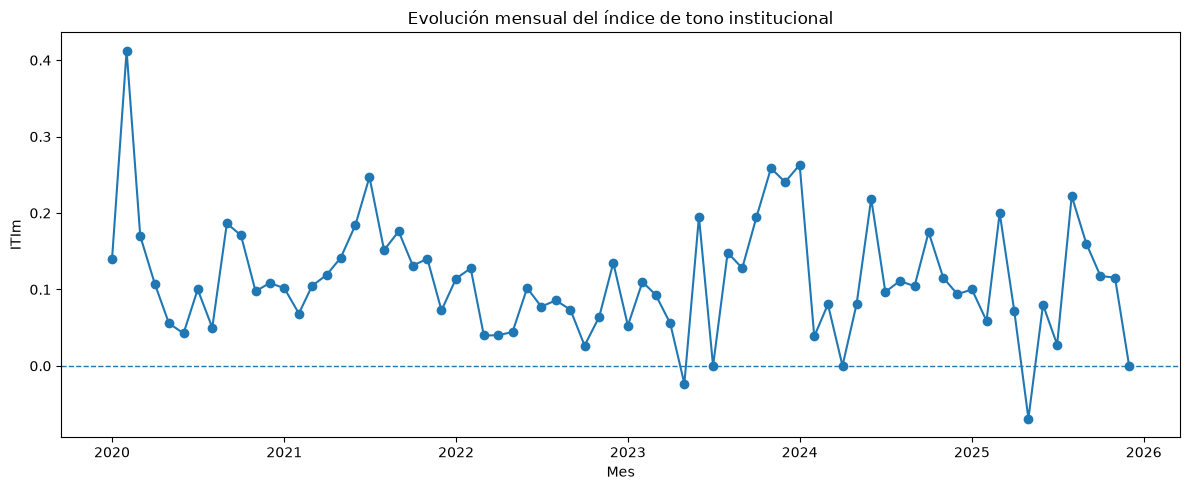

In [2]:
tweets = pd.read_csv(TWEETS_CLASIFICADOS)
indice = construir_indice_tono(tweets)
indice.to_csv(DATA_PROCESSED / "indice_tono_institucional_mensual.csv", index=False, encoding="utf-8-sig")
display(indice.head())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(indice["mes"], indice["ITI"], marker="o")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Evolución mensual del índice de tono institucional")
ax.set_xlabel("Mes")
ax.set_ylabel("ITIm")
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "evolucion_iti_mensual.png", dpi=150)
plt.show()

## Unión con el ICC

In [3]:
icc = pd.read_csv(ICC_INPUT)
# Compatibilidad con posibles nombres de columna
if "mes" not in icc.columns:
    if "fecha_mes" in icc.columns:
        icc = icc.rename(columns={"fecha_mes": "mes"})
    elif "fecha" in icc.columns:
        icc = icc.rename(columns={"fecha": "mes"})

icc["mes"] = pd.to_datetime(icc["mes"], errors="coerce")
if "ICC" not in icc.columns:
    posibles = [c for c in icc.columns if "confianza" in c.lower() or c.lower() == "icc"]
    if posibles:
        icc = icc.rename(columns={posibles[0]: "ICC"})
    else:
        raise ValueError("No se encuentra columna ICC en el archivo de ICC.")

comparativo = indice.merge(icc[["mes", "ICC"]], on="mes", how="left")
comparativo["icc_disponible"] = comparativo["ICC"].notna()
comparativo.to_csv(DATA_PROCESSED / "dataset_icc_sentimiento_mensual.csv", index=False, encoding="utf-8-sig")
print(comparativo["icc_disponible"].value_counts(dropna=False))
display(comparativo.head())

icc_disponible
True     68
False     4
Name: count, dtype: int64


,mes,n_negativo,n_neutro,n_positivo,total_tweets,pct_positivo,pct_negativo,pct_neutro,ITI,ICC,icc_disponible
0,2020-01-01,1,35,7,43,0.162791,0.023256,0.813953,0.139535,87.2,True
1,2020-02-01,1,55,41,97,0.422680,0.010309,0.567010,0.412371,85.7,True
2,2020-03-01,3,38,12,53,0.226415,0.056604,0.716981,0.169811,63.3,True
3,2020-04-01,0,25,3,28,0.107143,0.000000,0.892857,0.107143,49.9,True
4,2020-05-01,4,43,7,54,0.129630,0.074074,0.796296,0.055556,52.9,True


## Visualización conjunta ITIm–ICC

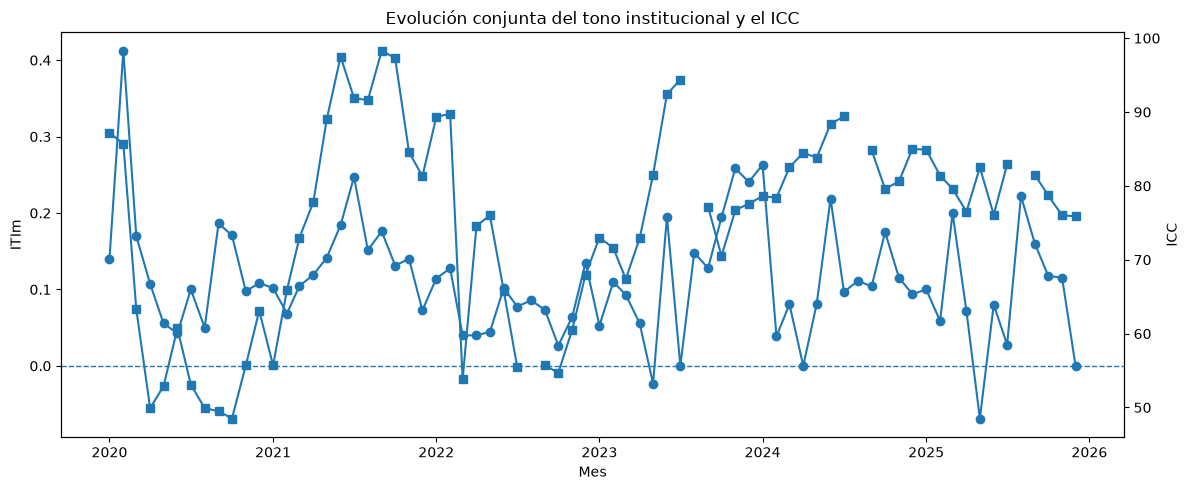

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(comparativo["mes"], comparativo["ITI"], marker="o", label="ITIm")
ax1.set_ylabel("ITIm")
ax1.axhline(0, linestyle="--", linewidth=1)
ax2 = ax1.twinx()
ax2.plot(comparativo["mes"], comparativo["ICC"], marker="s", label="ICC")
ax2.set_ylabel("ICC")
ax1.set_title("Evolución conjunta del tono institucional y el ICC")
ax1.set_xlabel("Mes")
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "evolucion_iti_icc.png", dpi=150)
plt.show()

## Correlación y desfases

Se calculan Pearson y Spearman en niveles y en diferencias intermensuales. También se exploran desfases de ±1 mes. Estos resultados no implican causalidad.

,metodo,n,correlacion,p_value,tipo,desfase,comparacion
0,pearson,67,0.252440,0.039310,niveles,-1,ITI_m vs ICC_m-1
1,spearman,67,0.307958,0.011237,niveles,-1,ITI_m vs ICC_m-1
2,pearson,62,0.166440,0.196040,diferencias_intermensuales,-1,ITI_m vs ICC_m-1
3,spearman,62,0.282145,0.026300,diferencias_intermensuales,-1,ITI_m vs ICC_m-1
4,pearson,68,0.204401,0.094526,niveles,0,ITI_m vs ICC_m
5,spearman,68,0.268901,0.026602,niveles,0,ITI_m vs ICC_m
6,pearson,63,0.176154,0.167278,diferencias_intermensuales,0,ITI_m vs ICC_m
7,spearman,63,0.048561,0.705471,diferencias_intermensuales,0,ITI_m vs ICC_m
8,pearson,67,0.100008,0.420693,niveles,1,ITI_m vs ICC_m+1
9,spearman,67,0.196849,0.110350,niveles,1,ITI_m vs ICC_m+1


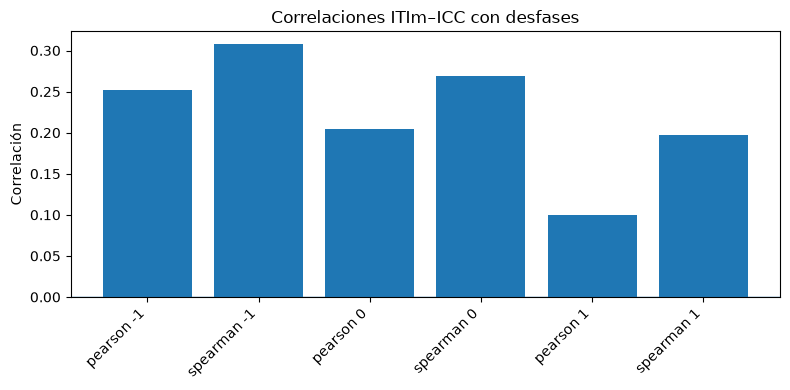

In [5]:
corr = tabla_correlaciones_desfases(comparativo, iti_col="ITI", icc_col="ICC")
corr.to_csv(OUTPUTS_TABLES / "correlaciones_iti_icc.csv", index=False, encoding="utf-8-sig")
display(corr)

corr_niveles = corr[corr["tipo"] == "niveles"].copy()
fig, ax = plt.subplots(figsize=(8, 4))
labels = corr_niveles["metodo"] + " " + corr_niveles["desfase"].astype(str)
ax.bar(labels, corr_niveles["correlacion"])
ax.axhline(0, linewidth=1)
ax.set_title("Correlaciones ITIm–ICC con desfases")
ax.set_ylabel("Correlación")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "desfases_temporales_iti_icc.png", dpi=150)
plt.show()

## Dispersión ITIm–ICC

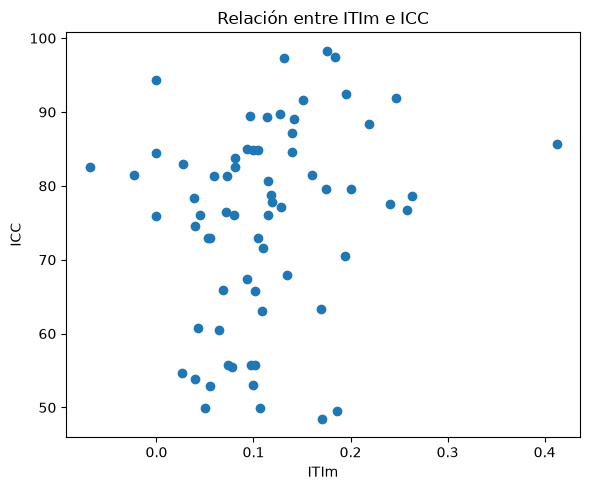

In [6]:
tmp = comparativo.dropna(subset=["ITI", "ICC"])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(tmp["ITI"], tmp["ICC"])
ax.set_title("Relación entre ITIm e ICC")
ax.set_xlabel("ITIm")
ax.set_ylabel("ICC")
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "correlacion_iti_icc.png", dpi=150)
plt.show()

## Eventos económicos de referencia

In [7]:
eventos = pd.DataFrame([
    {"periodo": "2020", "evento": "Pandemia COVID-19", "interpretacion": "Contexto de elevada incertidumbre económica y social."},
    {"periodo": "2021", "evento": "Recuperación económica", "interpretacion": "Reapertura progresiva y recuperación de actividad."},
    {"periodo": "2022", "evento": "Inflación y crisis energética", "interpretacion": "Presiones sobre precios, energía y poder adquisitivo."},
    {"periodo": "2023", "evento": "Estabilización parcial", "interpretacion": "Normalización gradual tras el shock inflacionario."},
    {"periodo": "2024-2025", "evento": "Seguimiento de estabilización/cambios", "interpretacion": "Periodo de comparación posterior para observar divergencias o alineación."},
])
eventos.to_csv(OUTPUTS_TABLES / "eventos_relevantes.csv", index=False, encoding="utf-8-sig")
display(eventos)

,periodo,evento,interpretacion
0,2020,Pandemia COVID-19,Contexto de elevada incertidumbre económica y ...
1,2021,Recuperación económica,Reapertura progresiva y recuperación de activi...
2,2022,Inflación y crisis energética,"Presiones sobre precios, energía y poder adqui..."
3,2023,Estabilización parcial,Normalización gradual tras el shock inflaciona...
4,2024-2025,Seguimiento de estabilización/cambios,Periodo de comparación posterior para observar...


## Resumen interpretativo

El resumen final debe completarse tras revisar los resultados numéricos. La interpretación debe usar lenguaje de asociación, alineación, desfase o divergencia, evitando afirmar causalidad.

In [8]:
resumen = pd.DataFrame([
    {"elemento": "caracter_analisis", "resultado": "Exploratorio y correlacional; no causal."},
    {"elemento": "meses_comparables", "resultado": int(comparativo["icc_disponible"].sum())},
    {"elemento": "meses_sin_icc", "resultado": int((~comparativo["icc_disponible"]).sum())},
    {"elemento": "nota", "resultado": "La interpretación sustantiva debe completarse tras revisar gráficos y correlaciones."},
])
resumen.to_csv(OUTPUTS_TABLES / "resumen_interpretacion_resultados.csv", index=False, encoding="utf-8-sig")
display(resumen)

,elemento,resultado
0,caracter_analisis,Exploratorio y correlacional; no causal.
1,meses_comparables,68
2,meses_sin_icc,4
3,nota,La interpretación sustantiva debe completarse ...
